<br>

## 🟢 로지스틱회귀분석


### 🟡 의사결정트리 (Decision Tree)

- 질문을 따라 분류해 나가는 트리 구조 (예: 20고개 게임)
- 데이터를 **완벽히 분류할 때까지** 트리를 확장 → 항상 훈련셋 정확도 100%
- 그래서 **과대적합**이 심함

#### ❗ 단점 보완을 위한 방법

- **하이퍼파라미터**로 트리 깊이 등을 제한해 과대적합 방지
- **특성 중요도**를 시각화할 수 있어 해석력이 뛰어남

<br>

### 🟡 앙상블 기법 (Ensemble)

#### ✅ 랜덤 포레스트 (Random Forest)

- 여러 트리를 **무작위로 만들고**, 예측 결과를 **평균**
- 과대적합을 줄이고 안정적임

#### ✅ 그래디언트 부스팅 (Gradient Boosting)

- 이전 모델의 **오류를 보완하며 학습**
- 트리가 계속 뻗지 않게 제어 → 과대적합 방지
- `sklearn`의 `GradientBoostingClassifier`
- **XGBoost**: 성능과 속도 모두 우수한 부스팅 구현


----- 로지스틱일 때 -----
훈련셋 평가 0.9619047619047619
테스트셋 평가 1.0
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]



----- 의사결정트리일 때 -----
훈련셋 평가 1.0
테스트셋 평가 1.0
특성의 중요도 [0.01911002 0.         0.42356658 0.5573234 ]


----- 수평막대 차트 그려보자! -----


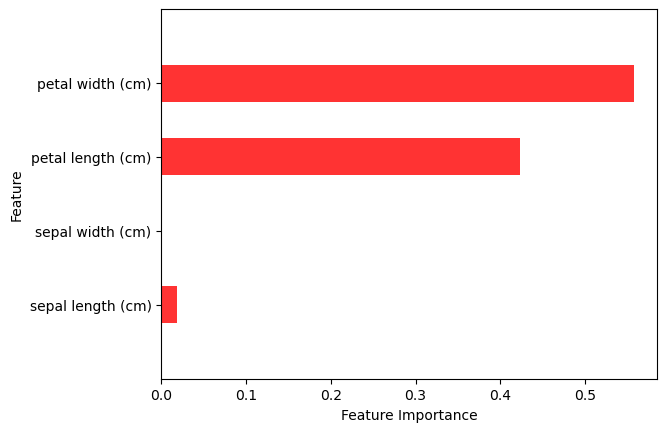



----- 랜덤포레스트 -----
훈련셋 평가 0.9619047619047619
테스트셋 평가 1.0
특성의 중요도 [0.11765195 0.0167683  0.43071732 0.43486243]

----- 랜덤포레스트 특성 중요도 차트 -----


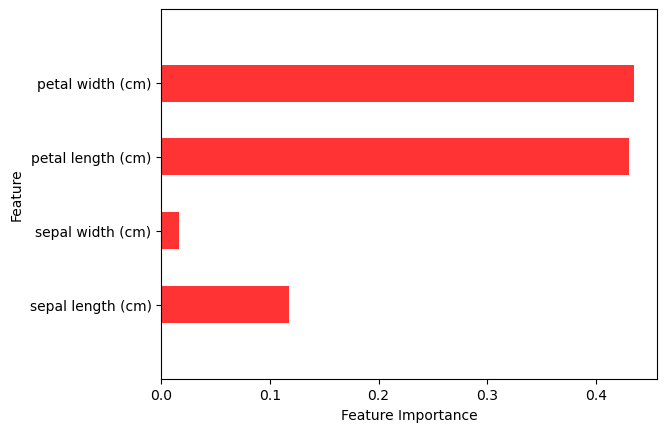


특성 중요도 순위:
             feature  importance
3   petal width (cm)    0.434862
2  petal length (cm)    0.430717
0  sepal length (cm)    0.117652
1   sepal width (cm)    0.016768


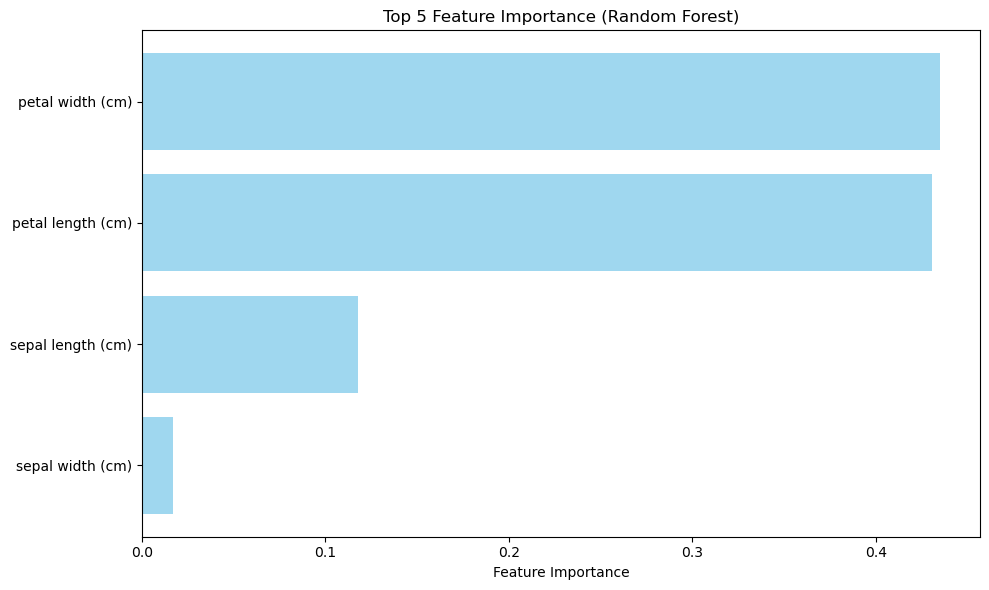

In [23]:
from sklearn.datasets import load_iris

# ===================================================
# 1. 데이터 준비
data = load_iris()  # Bunch 라는 클래스 타입

# ===================================================
# 2. 데이터를 나누기
X = data['data']  # 입력 데이터 (꽃의 길이, 너비 등) → 2차원 배열 (150행, 4열)
y = data['target']  # 출력 데이터 (품종 label: 0, 1, 2) → 1차원 배열 (150개)

# print(X[:10])  
# print(y)       

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                # 전체 데이터(x: 입력, y: 정답)
    test_size=0.3,       # 테스트 데이터 비율: 30%
    random_state=42      # 시드 고정 → 결과 재현 가능
)

# print(X_train.shape)  # (105, 4) → 훈련 샘플 105개, 특성 4개
# print(X_test.shape)   # (45, 4) → 테스트 샘플 45개, 특성 4개

# ===================================================
# 3. 데이터 시각화

# 데이터 전체를 확인하기 위해서, 
# 산점행렬(특성이 4개면 각 특성 대 특성으로만 그릴 수 있어서 차트 4x4=16, 
# 특성이 10개가 되면 10 x 10 100개 차트가 만들어진다.)

# scatter_matrix 차트가 직접 노가다로 그릴 수도 있고, DataFrame이 제공해준다.
# 아니면 Seaborm 차드를 사용한다.
# numpy 배열을 => DataFrame 으로 변환
import pandas as pd
import matplotlib.pyplot as plt  # 모든 차트는 이 라이브러리가 필요

iris_df = pd.DataFrame(X, columns = data.feature_names)   # numpt 배열과 컬러명으로

# pd.plotting.scatter_matrix(iris_df, 
#                             c = y,  # 각 점의 색상을 지정한다.   0, 1, 2 각자 다른 색 지정
#                             figsize=(15, 15), 
#                             marker='o', 
#                             hist_kwds={'bins': 20}, 
#                                      # 대각선의 히스토그램의 구간 개수
#                             s = 60,
#                             alpha = 0.8 # 투명도 / 1이 불투명, 0으로 갈 수록 투명하다.
# )  # 이거 많이 안쓰고, 보통 Seaborn 차트를 사용한다.
# plt.show()


# ===================================================
# 4. 모델 만들기
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)  # 이웃의 개수를 3개로 지정

# 학습을 시작한다. 학습한 내용은 모델 자체가 갖고 있고, 충분히 모델의 하이퍼파라미터가 지정되엇
# 최대한의 학습효과를 얻었다고 생각하면 모델을 지정해놓고 나중에 불러와서 다시 쓸 수 있다.

model.fit(X_train, y_train)  # 학습을 시작한다. 학습한 내용은 모델 자체가 갖고 있고, 충분히 모델의 하이퍼파라미터가 지정되엇
# 최대한의 학습효과를 얻었다고 생각하면 모델을 지정해놓고 나중에 불러와서 다시 쓸 수 있다.

# 예측하기
y_pred = model.predict(X_test)
# 본래의 테스트셋인 y_test와 비교해본다.
# print(y_pred)
# print(y_test)

# 평가하기
# print("훈련셋평가", model.score(X_train, y_train))
# print("테스트셋평가", model.score(X_test, y_test))

# 클래스 이름으로 출력
class_names = list(data.target_names)
# for i, j in zip(y_test, y_pred):
    # print(f"실제: {class_names[i]:20s} 예측: {class_names[j]}")


# 로지스틱 분류 : 2진, 다중분류, R은 2진분류만
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
print("----- 로지스틱일 때 -----")
print("훈련셋 평가", model.score(X_train, y_train))
print("테스트셋 평가", model.score(X_test, y_test))
print(model.predict(X_test))
print(y_test)


# ===================================================
print("\n\n")
# 5. 의사 결정 트리 (회귀와 분류 모두 가능하다.)
# 필연적으로 과대적합이 된다. 알고리즘 자체가 과대접합으로 간다.
# 의사결정트리 알고리즘은 특성의 중요도 파악용임
from sklearn.tree import DecisionTreeClassifier
# 트리 시작이 랜덤이라서, 시드를 잡아주지 않으면 만들어질때마다 다르게 나온다.
model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)
print("----- 의사결정트리일 때 -----")
print("훈련셋 평가", model.score(X_train, y_train))
print("테스트셋 평가", model.score(X_test, y_test))
print("특성의 중요도", model.feature_importances_)  # 특성의 중요도 파악용



# ===================================================
print("\n\n----- 수평막대 차트 그려보자! -----")
# 6. 수평막대 차트를 그려보자! : 중요도를 그려보자
import matplotlib.pyplot as plt
import numpy as np

def tree_chart(model, feature_name):
    # 수평막대개수 구하기 : 특성의 개수만큼 구하면 된다.
    n_features = len(model.feature_importances_)
    # barh - 수평막대그래프
    plt.barh(np.arange(n_features), 
                model.feature_importances_, 
                align='center',
                height=0.5,
                color='red',
                alpha=0.8
            )
    plt.yticks(np.arange(n_features), feature_name)  # 특성의 이름을 출력
    plt.xlabel("Feature Importance")  # 중요도
    plt.ylabel("Feature")  # 특성의 이름
    plt.ylim(-1, n_features)  # 막대의 높이를 조절 / 눈금 범위
    plt.show()

tree_chart(model, np.array(data.feature_names))


# ===================================================
print("\n\n----- 랜덤포레스트 -----")
# 7. 랜덤포레스트
# 랜덤포레스트는 트리를 여러개 만들어서 평균을 낸다.
# 앙상블의 일종, 과대적합의 위험을 가지고 있다.
from sklearn.ensemble import RandomForestClassifier
# random_state=1 를 꼭 지정해줘야한다.
# 너무 작으면 과대적합문제가 발생한다. 일반화
# 모델을 생설할때 전달되는 파라미터를 하이퍼파라미터라고 하고 이 값들을 적절히 활용해서 과대적합도 과소적합도 막아서 일반화해야한다.
model = RandomForestClassifier(random_state=1,
                                max_depth=3,  # 트리의 깊이
                                n_estimators=100,  # 트리의 개수 (너무 크면 많이 걸림)
                                )

model.fit(X_train, y_train)
print("훈련셋 평가", model.score(X_train, y_train))
print("테스트셋 평가", model.score(X_test, y_test))
print("특성의 중요도", model.feature_importances_)




